# Chapter 1: Introduction to iEEG Sleep Data Analysis with MNE Python

This notebook will guide you through the basics of analyzing intracranial EEG (iEEG) sleep data.
You will learn how to:

...

Using matplotlib as 2D backend.


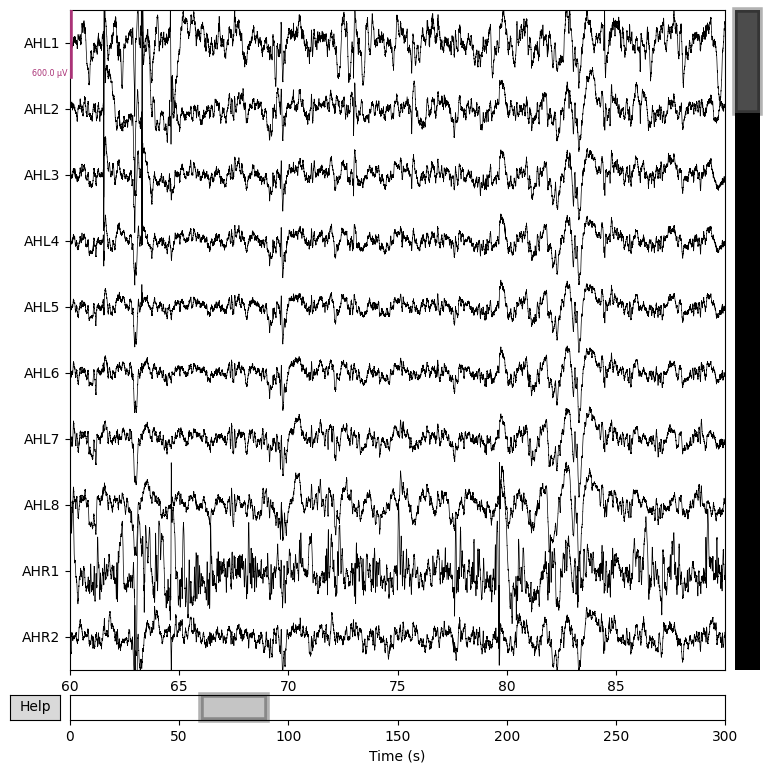

The plot shows voltage (microvolts) over time for the first 3 channels.


In [ ]:
# Plot 30 seconds of data starting at 60 seconds

raw_copy = raw.copy()
raw_copy.set_annotations(None) # remove annotations temporarily for plotting

raw_copy.plot(start=60, duration=30, n_channels=10, scalings=dict(eeg=300e-6), title='iEEG Signal')
print("The plot shows voltage (microvolts) over time for the first 3 channels.")

This is actual electrical activity from inside a human brain, recorded by electrodes placed directly inside the brain of a patient. Each trace represents one electrode, and every wiggle is thousands of neurons firing in synchrony.

Let's have a look at the **Power Spectrum Density (PSD)**. PSD describes how the power (energy) of a neural signal is distributed across different frequencies. Instead of looking at the signal over time, PSD shows which frequencies dominate the activity.

In iEEG, this matters because brain activity is strongly frequency-specific. Different frequency bands (e.g., theta, alpha, gamma) are linked to distinct neural processes like memory, attention, or local neuronal firing. PSD lets you quantify these components objectively.

It is important for iEEG because it helps:

*   identify **neural rhythms** and their changes across conditions
*   detect **pathological** activity (e.g., abnormal high-frequency power in epilepsy)
*   compare brain states (rest vs task, different cognitive conditions)
*   **extract features** for analysis and machine learning

In short, PSD turns raw signals into interpretable frequency-based information, which is central to understanding iEEG data.

Effective window size : 1.024 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_23587/983361717.py:3: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = raw.compute_psd().plot(picks='data', exclude='bads', amplitude=False)


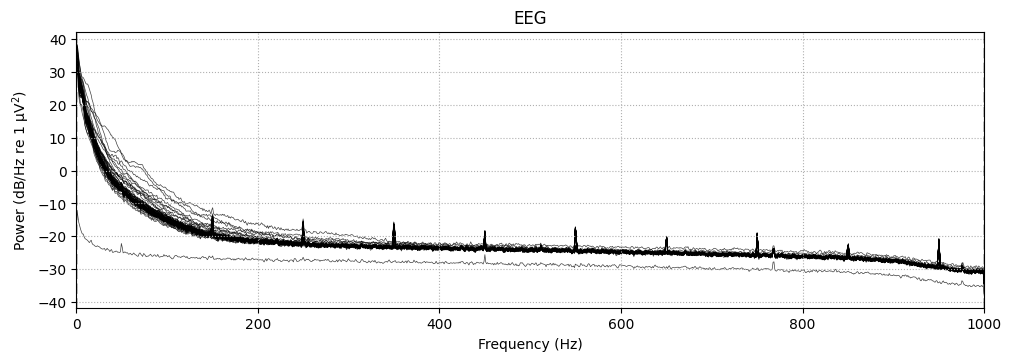

In [ ]:
# Compute and plot Power Spectrum Density (PSD)

fig = raw.compute_psd().plot(picks='data', exclude='bads', amplitude=False)

This plot reveals several fascinating features of brain electrical activity:

**The 1/f Pattern (Pink Noise)**
Notice how power decreases dramatically as frequency increases - this is the characteristic "1/f" or pink noise pattern of brain activity. The brain produces much stronger low-frequency oscillations than high-frequency ones. This isn't random; it reflects the fundamental organization of neural networks where large populations of neurons synchronize at slower rhythms.

**The Sharp Peaks Around 150 Hz and Harmonics**
See those tall, narrow spikes at regular intervals (around 250, 350 Hz, etc.)? These are **electrical line noise** - artifacts from the power grid in the recording environment. In Europe, mains electricity runs at 50 Hz, and you're seeing the fundamental frequency plus its harmonics (multiples). This is normal in EEG/iEEG recordings and would typically be filtered out for analysis. See the figure with different X-axis for better visualisation.

**Why the Y-axis is Negative**
Power is plotted in decibels (dB), which uses a logarithmic scale. The negative values don't mean "negative power" - they indicate power levels relative to a reference. What matters is the relative differences between frequencies, not the absolute numbers.

**The Low-Frequency Dominance**
The highest power is concentrated below 10 Hz - the delta and theta ranges. This makes sense for sleep data, where slow oscillations dominate. During deep sleep, you'd see even more pronounced power in the 0.5-4 Hz delta band.

**Multiple Overlapping Lines**
Each line represents a different electrode. The fact that they mostly overlap shows relatively consistent spectral properties across recording sites, though some channels show slightly different profiles - possibly due to their anatomical location or local neural activity.
